In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from specula.mmlib.analyse_data import get_sim_data
from specula.mmlib.utils import show_psf, get_reference_psf
from specula.lib.radial_profile import compute_radial_profile

2026-05-21 16:18:28,101 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-21 16:18:28,216 [INFO]: [specula]: Default device is GPU number 0
2026-05-21 16:18:29,288 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-21 16:18:29,288 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-21 16:18:29,290 [INFO]: [specula]: Default device is GPU number 0
2026-05-21 16:18:29,290 [INFO]: [specula]: Default device is GPU number 0


In [2]:
cascading_dir = '/raid1/mmenessini/results/Cascading'
xao_dir = '/raid1/mmenessini/results/XAO'
calib_dir = '/raid1/mmenessini/calibration/XAO'

In [ ]:
tn1kHz = '20260520_102745'
tn2kHz = '20260520_110242'
tn4kHz = '20260520_115326'
tnMod1 = '20260520_120617'
tnMod0 = '20260520_123548'

# Cascading
tnSAO = '20260520_123548' # cascading_iirfilter_1300modes, g = 0.15

Using data directory: /raid1/mmenessini/results/XAO/20260520_102745
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_opt_psf type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260520_110242
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: coro_opt_psf type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
Using data directory: /raid1/mmenessini/results/XAO/20260520_115326
key: coro_psf type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_modes type: <

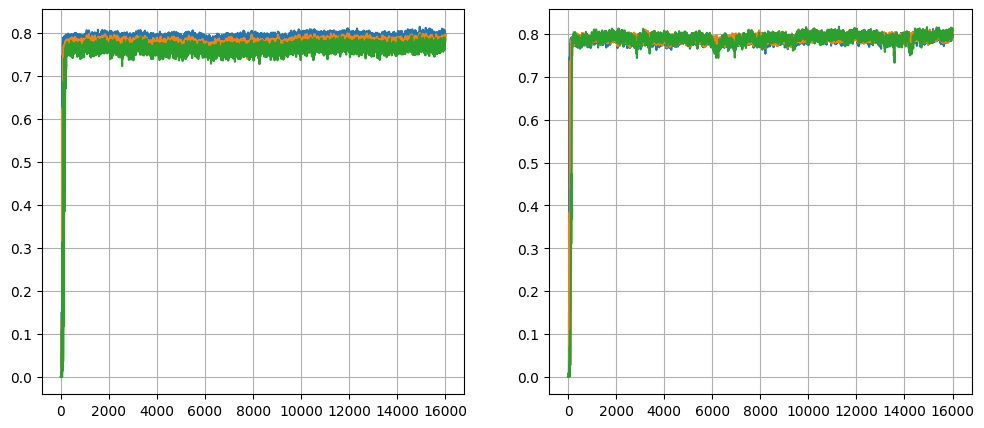

In [21]:
data1kHz = get_sim_data(root_dir=xao_dir,tn=tn1kHz)
data2kHz = get_sim_data(root_dir=xao_dir,tn=tn2kHz)
data4kHz = get_sim_data(root_dir=xao_dir,tn=tn4kHz)
dataMod1 = get_sim_data(root_dir=xao_dir,tn=tnMod1)
dataMod0 = get_sim_data(root_dir=xao_dir,tn=tnMod0)

sr1k = data1kHz['sr']
sr2k = data2kHz['sr']
sr4k = data4kHz['sr']
sr1 = dataMod1['sr']
sr0 = dataMod0['sr']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(sr4k)
plt.plot(sr2k)
plt.plot(sr1k)
plt.grid()
plt.subplot(1,2,2)
plt.plot(sr4k)
plt.plot(sr1)
plt.plot(sr0)
plt.grid()

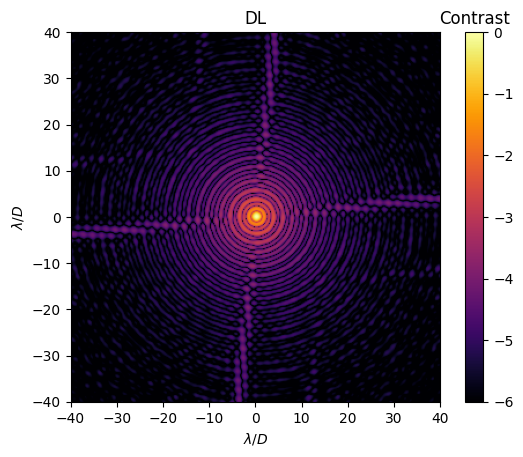

In [22]:
oversampling = 4
pupil_tag = 'vlt_pupil_160pixels'
psf_dl = get_reference_psf(root_dir=calib_dir,pupil_tag=pupil_tag,nd=oversampling)

show_psf(psf_dl, title='DL', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-6, maxVal=np.max(psf_dl))

In [32]:
dt = 0.00025
init = int(0.5/dt)

coro_psf1kHz = data1kHz['coro_psf']
opt_coro_psf = data1kHz['coro_opt_psf']

coro_psf1kHz_std = np.sqrt(np.mean(coro_psf1kHz[init:]**2,axis=0))
opt_coro_psf_std = np.std(opt_coro_psf,axis=0) #np.sqrt(np.mean(opt_coro_psf[init:]**2,axis=0))

In [33]:
coro_psf2kHz = data2kHz['coro_psf']
coro_psf2kHz_std = np.sqrt(np.mean(coro_psf2kHz[init:]**2,axis=0))

coro_psf4kHz = data4kHz['coro_psf']
coro_psf4kHz_std = np.sqrt(np.mean(coro_psf4kHz[init:]**2,axis=0))

In [34]:
coro_psfmod1 = dataMod1['coro_psf']
coro_psfmod1_std = np.sqrt(np.mean(coro_psfmod1[init:]**2,axis=0))

coro_psfmod0 = dataMod0['coro_psf']
coro_psfmod0_std = np.sqrt(np.mean(coro_psfmod0[init:]**2,axis=0))

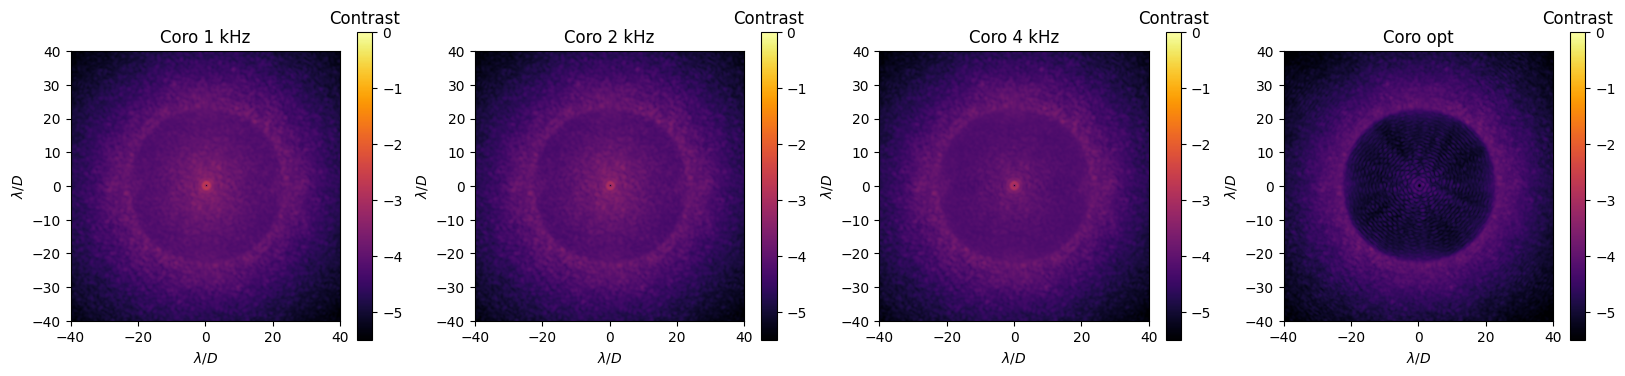

In [35]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf1kHz_std, title='Coro 1 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psf2kHz_std, title='Coro 2 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psf4kHz_std, title='Coro 4 kHz', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

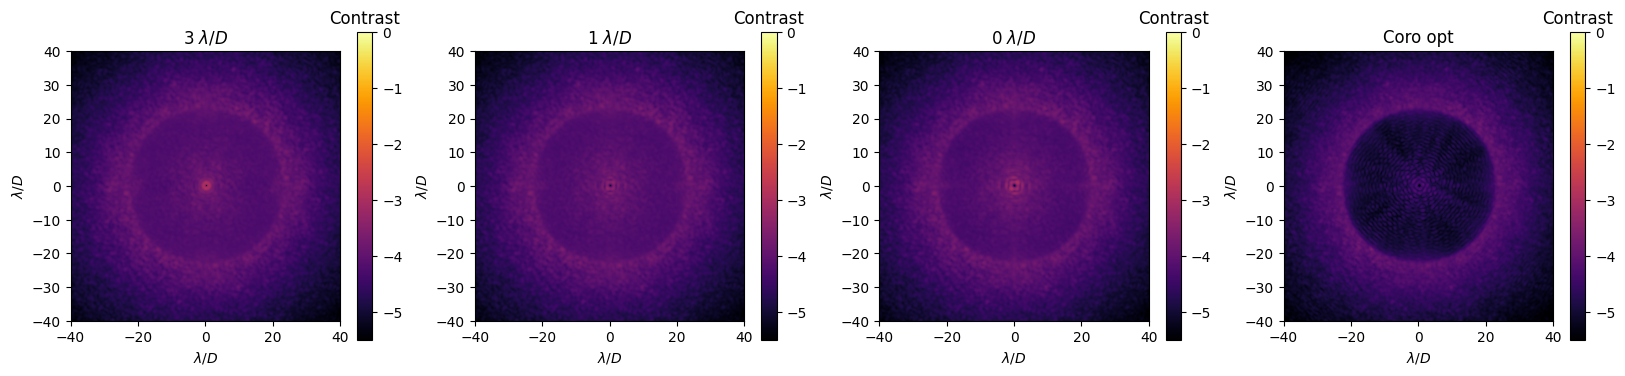

In [36]:
plt.figure(figsize=(20,4))
plt.subplot(1,4,1)
show_psf(coro_psf4kHz_std, title=r'3 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,2)
show_psf(coro_psfmod1_std, title=r'1 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,3)
show_psf(coro_psfmod0_std, title=r'0 $\lambda/D$', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))
plt.subplot(1,4,4)
show_psf(opt_coro_psf_std, title='Coro opt', cmap='inferno', ext=0.5, oversampling=oversampling,  vmin=-5.5, maxVal=np.max(psf_dl))

In [37]:
# rad_psf_dl, dist = compute_radial_profile(psf_dl)
rad_psf1kHz_coro, dist = compute_radial_profile(coro_psf1kHz_std)
rad_psf2kHz_coro, dist = compute_radial_profile(coro_psf2kHz_std)
rad_psf4kHz_coro, dist = compute_radial_profile(coro_psf4kHz_std)
rad_psfmod1_coro, dist = compute_radial_profile(coro_psfmod1_std)
rad_psfmod0_coro, dist = compute_radial_profile(coro_psfmod0_std)
rad_psf_opt_coro, dist = compute_radial_profile(opt_coro_psf_std)
# rad_psf2kHz_opt_coro, dist = compute_radial_profile(opt_coro_psf2kHz_std)

Text(0.5, 0, '$\\lambda/D$')

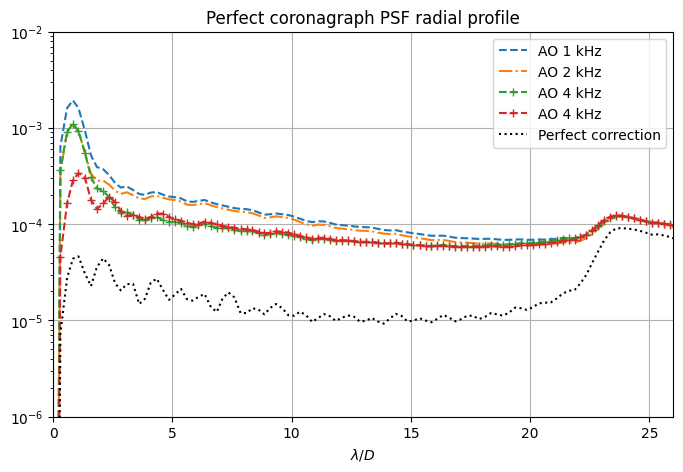

In [38]:

plt.figure(figsize=(8,5))
plt.plot(dist/oversampling, rad_psf1kHz_coro/np.max(psf_dl), '--', label=r'AO 1 kHz')
plt.plot(dist/oversampling, rad_psf2kHz_coro/np.max(psf_dl), '-.', label=r'AO 2 kHz')
plt.plot(dist/oversampling, rad_psf4kHz_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psfmod1_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
# plt.plot(dist/oversampling, rad_psfmod0_coro/np.max(psf_dl), '--+', label=r'AO 4 kHz')
plt.plot(dist/oversampling, rad_psf_opt_coro/np.max(psf_dl), ':', c='k', label=r'Perfect correction')
plt.legend()
plt.yscale('log')
plt.xlim([0,26])
plt.ylim([1e-6,1e-2])
plt.grid()
plt.title('Perfect coronagraph PSF radial profile')
plt.xlabel(r'$\lambda/D$')